In [61]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()
library(ComplexHeatmap)
library(circlize)

# 导入文件

In [137]:
# 导入orfs
orfs_path <- "../../results/all_samples.ibaq_b_with_total.tsv"
fread_c(orfs_path) -> orfs
colnames(orfs)
head(orfs,1)
# 样本数量
n_distinct(orfs$Sample)
# orfs总数
n_distinct(orfs$ORF_id)
# 过滤掉污染
orfs %>% filter(!grepl("Cont",ORF_id)) -> orfs
orfs %>% rename(Protein=ORF_id) -> orfs
n_distinct(orfs$Protein)

[1] "ORF_id"                      "iBAQ_B"                     
 [3] "iBAQ_A"                      "Available"                  
 [5] "TotalIntensity"              "ORF_type"                   
 [7] "Start_codon"                 "Isoform_id"                 
 [9] "Chr"                         "Strand"                     
[11] "ORF_seq"                     "ORF_length"                 
[13] "Geneid"                      "Isoform_structural_category"
[15] "Isoform_subcategory"         "is_uniprot"                 
[17] "is_canonical"                "All_peptide_n"              
[19] "Unique_peptide_n"            "Theo_peptide_n"             
[21] "Sample"

,ORF_id,iBAQ_B,iBAQ_A,Available,TotalIntensity,ORF_type,Start_codon,Isoform_id,Chr,Strand,⋯,ORF_length,Geneid,Isoform_structural_category,Isoform_subcategory,is_uniprot,is_canonical,All_peptide_n,Unique_peptide_n,Theo_peptide_n,Sample
,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<int>,<int>,<chr>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,1229838,5071184,TRUE,410765939,canonical,ATG,PB.10027.4,chr12,-,⋯,334,LDHB,full-splice_match,reference_match,FALSE,TRUE,15,6,81,108GM1


[1] 197

[1] 27860

[1] 27613

In [139]:
# 导入样本的源数据信息
sample_metadata_path="../../MS_res_from_Galaxy/merge_public_in_house/metadata.formal.v2.txt"
read.table(sample_metadata_path,header = F,sep=",") -> sample_metadata
colnames(sample_metadata) <- c("Sample","Enzyme","Period","Enrichment")
reformat_s <- function(df){
  df$Sample %>% gsub("-","_",.) -> df$Sample
  return(df)
}
reformat_s(sample_metadata) -> sample_metadata
head(sample_metadata,1)
nrow(sample_metadata)

,Sample,Enzyme,Period,Enrichment
,<chr>,<chr>,<chr>,<chr>
1,Fetal_Brain_bRP_Elite_15_f01,Trypsin,fetal,No_enrichment


[1] 197

## 总蛋白、经典和非经典蛋白质数量

In [142]:
# 得到必需列名进入下游分析
orfs %>% distinct(Protein,Sample) -> all_sample_sep
n_distinct(all_sample_sep$Protein)
all_sample_sep %>% merge(sample_metadata,by = "Sample") %>% arrange(Enrichment,Enzyme) -> all_sample_sep_m_meta
head(all_sample_sep_m_meta,1)
all_sample_sep_m_meta %>% filter(grepl("^sp",Protein) |grepl("canonical",Protein)) -> all_sample_sep_m_meta_cano
n_distinct(all_sample_sep_m_meta_cano$Protein)
all_sample_sep_m_meta %>% filter(grepl("^PB",Protein) & !grepl("canonical",Protein))  -> all_sample_sep_m_meta_uncano
n_distinct(all_sample_sep_m_meta_uncano$Protein)
create_path( "../../results/S4/")
fwrite(all_sample_sep_m_meta,file = "../../results/S4/all_sample_sep_m_meta.txt",sep='\t')

[1] 27613

,Sample,Protein,Enzyme,Period,Enrichment
,<chr>,<chr>,<chr>,<chr>,<chr>
1,21pcw_1_C8_T_T,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,Trypsin,21pcw,C8


[1] 9932

[1] 17681

# 饱和曲线图

In [143]:
output_path <- "../../figures/cumu_heatmap"
##### Saturation Plot #####
# sample_order <- sample(sample_metadata$Sample)
# sample_order <- sample_metadata %>% arrange(Enrichment,Enzyme,Replicate) %>% .$Sample
set.seed(123)
sample_order <- all_sample_sep_m_meta %>% .$Sample %>% unique() %>% sample()
# 1. 蛋白累积分析（带柱状图）
res_protein <- cumu_combo_plot(
  df = orfs,
  sample_order = sample_order,
  target_col = "Protein",
  show_bar = TRUE
)
ggsave(p,filename=o("cumu_pro_sample_n.pdf"),height = 5,width = 8)
ggsave(res_protein$version_sampleName,filename=o("cumu_pro_sample_name.pdf"),height = 5,width = 8)

In [170]:
head(all_sample_sep_m_meta)

,Sample,Protein,Enzyme,Period,Enrichment
,<chr>,<chr>,<chr>,<chr>,<chr>
1,21pcw_1_C8_T_T,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,Trypsin,21pcw,C8
2,21pcw_1_C8_T_T,PB.1003.3:chr1:+|10|581:117:393|canonical|ATG,Trypsin,21pcw,C8
3,21pcw_1_C8_T_T,PB.1004.25:chr1:+|3|2053:52:1792|canonical|ATG,Trypsin,21pcw,C8
4,21pcw_1_C8_T_T,PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG,Trypsin,21pcw,C8
5,21pcw_1_C8_T_T,PB.10048.74:chr12:+|12|1594:186:780|noncoding|ATG,Trypsin,21pcw,C8
6,21pcw_1_C8_T_T,PB.10135.101:chr12:-|1|3224:69:2733|noncoding|ATG,Trypsin,21pcw,C8


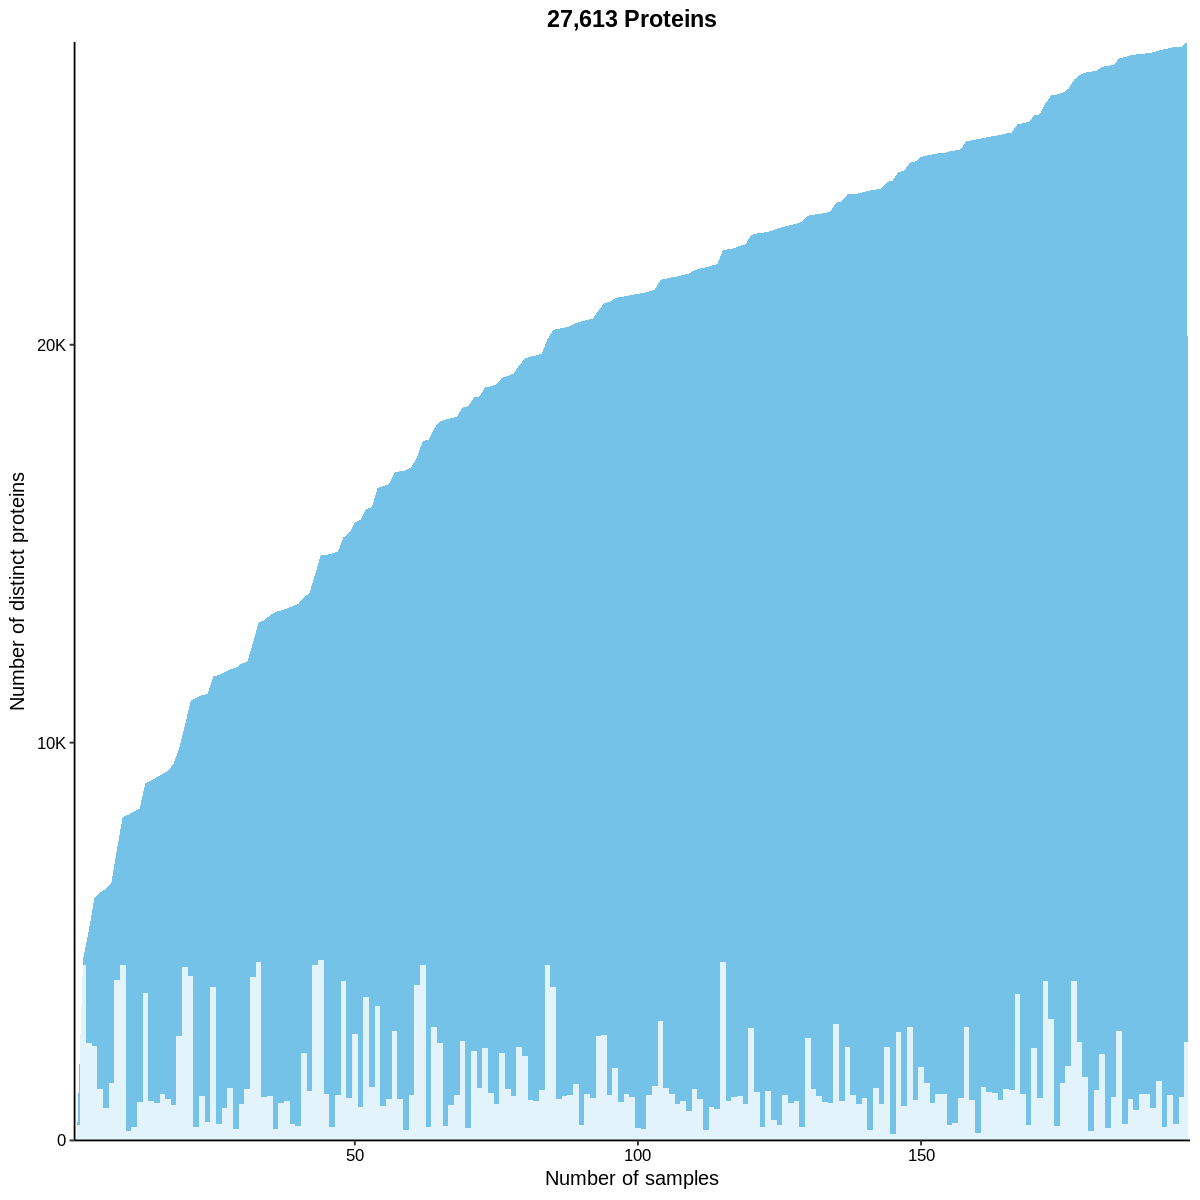

In [144]:
# 绘图
# d08e8f
cumulative_data=res_protein$plot_data
p <- ggplot(cumulative_data, aes(x = SampleCount, y = CumulativeUnique)) +
  geom_area(fill = "#1999da", alpha = 0.6) +  # 蓝灰色填充
  # 添加底部的条形图显示每个样本新增的肽段
  geom_col(aes(y = n), fill = "white", alpha = 0.8, width = 1) +
  labs(x = "Number of samples",
       y = "Number of distinct proteins",
       title = paste0(format(max(cumulative_data$CumulativeUnique), 
                            big.mark = ","), " Proteins")) +
  theme_3() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    panel.grid.minor = element_blank()
  ) +
  scale_y_continuous(
    labels = function(x) {
      ifelse(x >= 1e6, paste0(x/1e6, "M"), 
             ifelse(x >= 1e3, paste0(x/1e3, "K"), x))
    },
    expand = c(0, 0)
  ) +
  scale_x_continuous(expand = c(0, 0))

# 显示图形
print(p)

# 保存图形
ggsave(p, filename=o("cumu_pro_sample_n_fill.pdf"),
       width = 10, height = 6, dpi = 300, bg = "white")

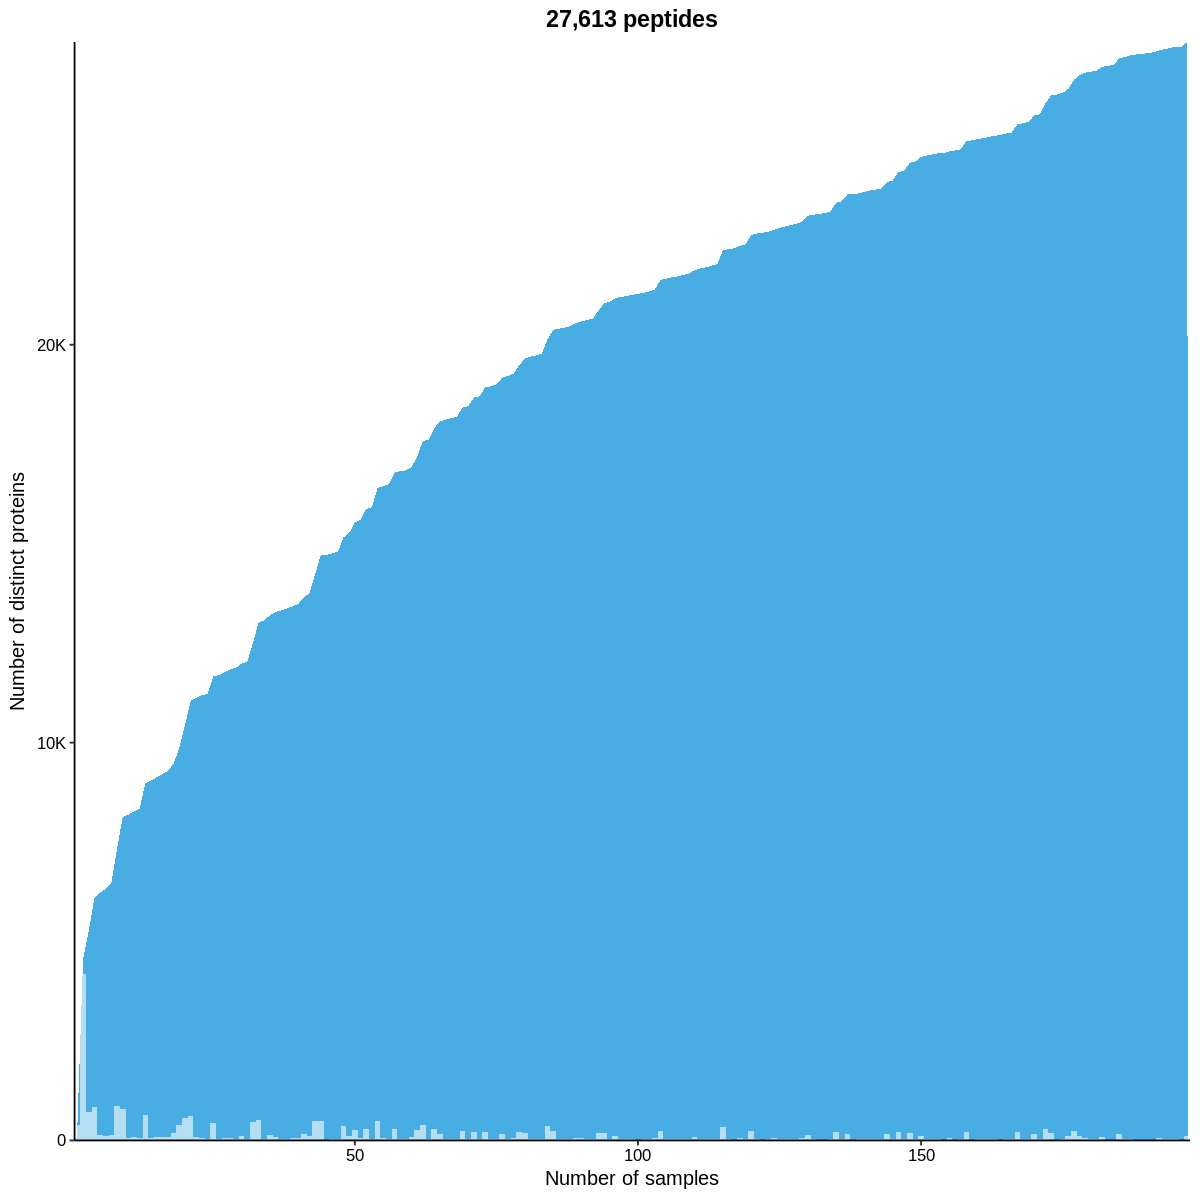

In [173]:
library(ggplot2)
library(dplyr)

# 准备数据：计算每个样本添加时新增的独特肽段
calculate_cumulative_peptides <- function(df) {
  # 获取所有样本
  samples <- unique(df$Sample)
  n_samples <- length(samples)
  
  # 随机排列样本顺序（可以运行多次取平均）
set.seed(123)
  samples_order <- sample(samples)
  
  # 初始化
  cumulative_peptides <- character(0)
  result <- data.frame(
    sample_index = integer(),
    cumulative_unique = integer(),
    new_peptides = integer()
  )
  
  # 逐个添加样本
  for (i in 1:n_samples) {
    current_sample <- samples_order[i]
    current_peptides <- df$Protein[df$Sample == current_sample]
    
    # 计算新增的独特肽段
    new_unique <- setdiff(current_peptides, cumulative_peptides)
    cumulative_peptides <- unique(c(cumulative_peptides, current_peptides))
    
    result <- rbind(result, data.frame(
        sample=current_sample,
      sample_index = i,
      cumulative_unique = length(cumulative_peptides),
      new_peptides = length(new_unique),
        current_peptides = length(unique(current_peptides))
    ))
  }
  
  return(result)
}

# 计算累积数据
cumulative_data <- calculate_cumulative_peptides(all_sample_sep_m_meta)

# 绘图
p <- ggplot(cumulative_data, aes(x = sample_index, y = cumulative_unique)) +
  geom_area(fill = "#1999da", alpha = 0.8) +  # 蓝灰色填充
  # 添加底部的条形图显示每个样本新增的肽段
  geom_col(aes(y = new_peptides), fill = "white", alpha = 0.6, width = 1) +
  labs(x = "Number of samples",
       y = "Number of distinct proteins",
       title = paste0(format(max(cumulative_data$cumulative_unique), 
                            big.mark = ","), " peptides")) +
  theme_3() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    panel.grid.minor = element_blank()
  ) +
  scale_y_continuous(
    labels = function(x) {
      ifelse(x >= 1e6, paste0(x/1e6, "M"), 
             ifelse(x >= 1e3, paste0(x/1e3, "K"), x))
    },
    expand = c(0, 0)
  ) +
  scale_x_continuous(expand = c(0, 0))

# 显示图形
print(p)

# 保存图形
ggsave(p, filename = o("cumu_pro_sample_n_fill_distinct.pdf"),
       width = 10, height = 6, dpi = 300, bg = "white")

## 平均每个run鉴定到的蛋白质

In [169]:
summary(res_protein$plot_data$n)
head(res_protein$plot_data)
nrow(res_protein$plot_data)
select(res_protein$plot_data,Sample,n) %>% fwrite("../../results/sample.unique.protein.identification.txt",sep = ",")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    169     911    1147    1541    2206    4537 

,Sample,Targets,CumulativeUnique,SampleCount,n
,<fct>,<list>,<int>,<int>,<int>
1,Fetal_Brain_Gel_Velos_16_f21,PB.10027....,383,1,383
2,21pcw_3_PCP_T_T,PB.10023....,4560,2,4421
3,21pcw_2_C8_T_GC,PB.10167....,5269,3,2439
4,21pcw_3_PAGE_T_T,PB.10103....,6098,4,2382
5,108SVZ2,PB.10305....,6225,5,1281
6,Fetal_Brain_bRP_Elite_15_f04,PB.10205....,6327,6,823


[1] 197

# public和in house数据的比较

In [146]:
output_path <- "../../figures/public_in_house_compare"
orfs %>% merge(sample_metadata,by = "Sample") -> orfs_m_meta
head(orfs_m_meta,1)
cols <- c("Protein","ORF_length","is_canonical","Enrichment")
orfs_m_meta[,cols] -> orfs_m_meta_selected
df <- orfs_m_meta_selected %>%
  mutate(Enrichment_group = ifelse(Enrichment == "No_enrichment", 
                                    "No_enrichment", 
                                    "Enrichment")) %>%
  distinct()

,Sample,Protein,iBAQ_B,iBAQ_A,Available,TotalIntensity,ORF_type,Start_codon,Isoform_id,Chr,⋯,Isoform_structural_category,Isoform_subcategory,is_uniprot,is_canonical,All_peptide_n,Unique_peptide_n,Theo_peptide_n,Enzyme,Period,Enrichment
,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<lgl>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1,108cortex1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,642360.8,2648747,TRUE,214548499,canonical,ATG,PB.10027.4,chr12,⋯,full-splice_match,reference_match,FALSE,TRUE,14,6,81,Trypsin,fetal,No_enrichment


## venn plot 

Warning message in brewer.pal(2, "Set2"):
“minimal value for n is 3, returning requested palette with 3 different levels
”


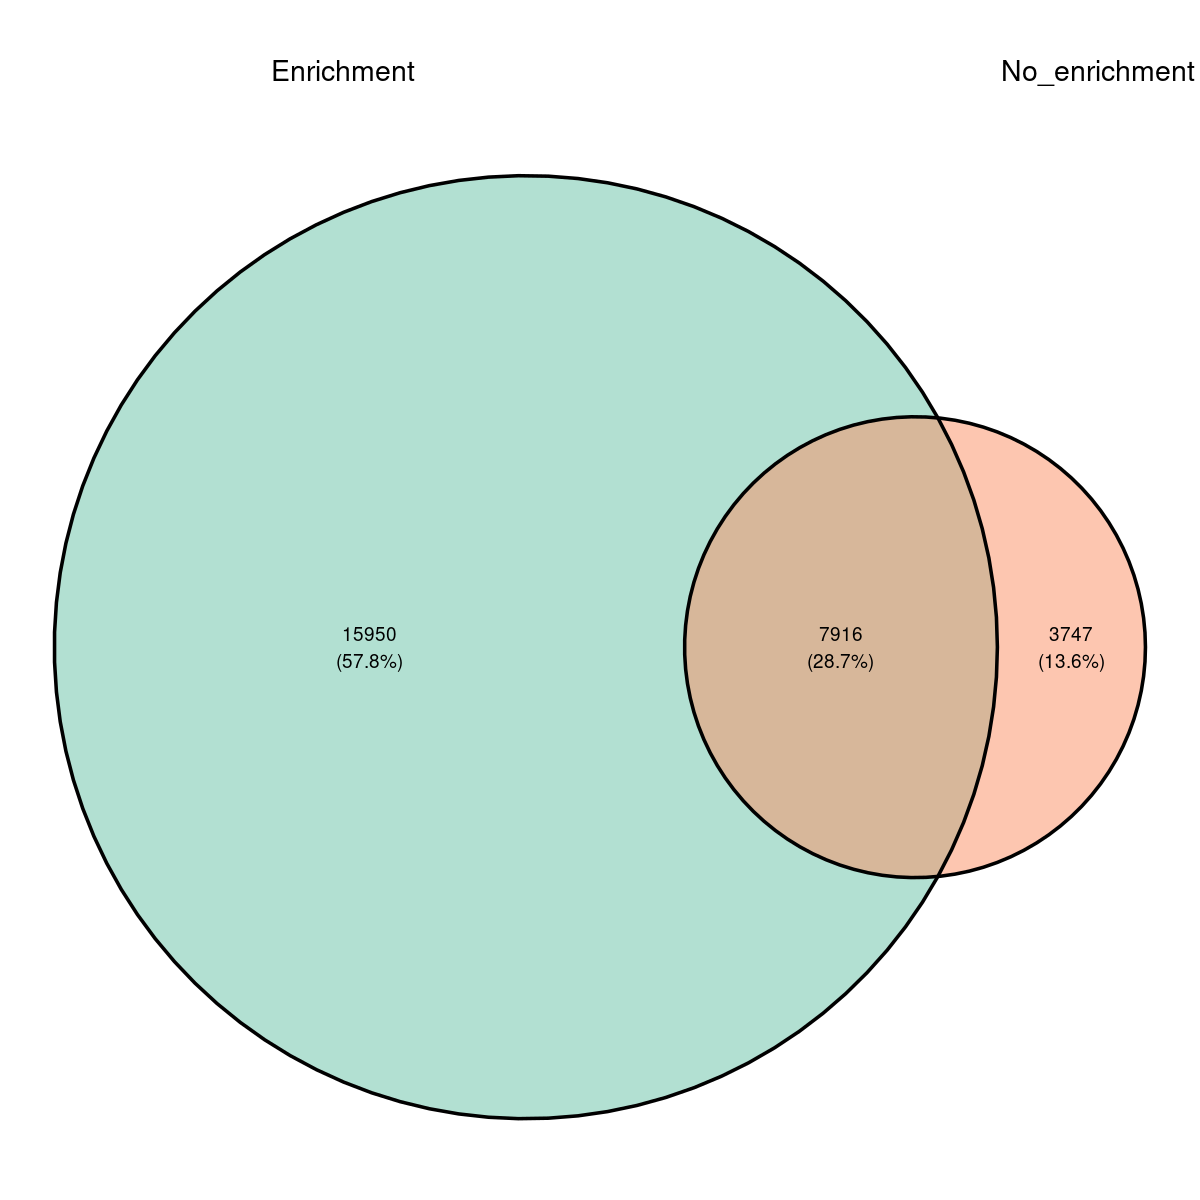

In [147]:
enrichment_ids <- df %>%
  filter(Enrichment_group == "Enrichment") %>%
  pull(Protein)
no_enrichment_ids <- df %>%
  filter(Enrichment_group == "No_enrichment") %>%
  pull(Protein)
l <- list(Enrichment=enrichment_ids,No_enrichment=no_enrichment_ids)
 ggvenn(l, fill_color = brewer.pal(2,"Set2"), names(l), 
                auto_scale = T,set_name_size=6) -> p_venn
p_venn
ggsave(p_venn,filename=o("public_in_house_overlap.pdf"),height = 5,width = 8)

## 长度比例分组分bin

### ORF length分组统计

In [149]:
print("ORF_length描述统计：")
print(df %>%
  group_by(Enrichment_group) %>%
  summarise(
    n = n(),
    mean = mean(ORF_length),
    median = median(ORF_length),
    sd = sd(ORF_length),
    min = min(ORF_length),
    max = max(ORF_length)
  ))
# 使用Wilcoxon秩和检验（Mann-Whitney U检验）- 更稳健
wilcox_result <- wilcox.test(ORF_length ~ Enrichment_group, 
                              data = df)
print("Wilcoxon秩和检验结果：")
print(wilcox_result)

[1] "ORF_length描述统计："
# A tibble: 2 × 7
  Enrichment_group     n  mean median    sd   min   max
  <chr>            <int> <dbl>  <int> <dbl> <int> <int>
1 Enrichment       39323  335.    213  370.     6  2755
2 No_enrichment    11663  354.    240  374.     7  2755
[1] "Wilcoxon秩和检验结果："

	Wilcoxon rank sum test with continuity correction

data:  ORF_length by Enrichment_group
W = 219982414, p-value = 2.334e-11
alternative hypothesis: true location shift is not equal to 0



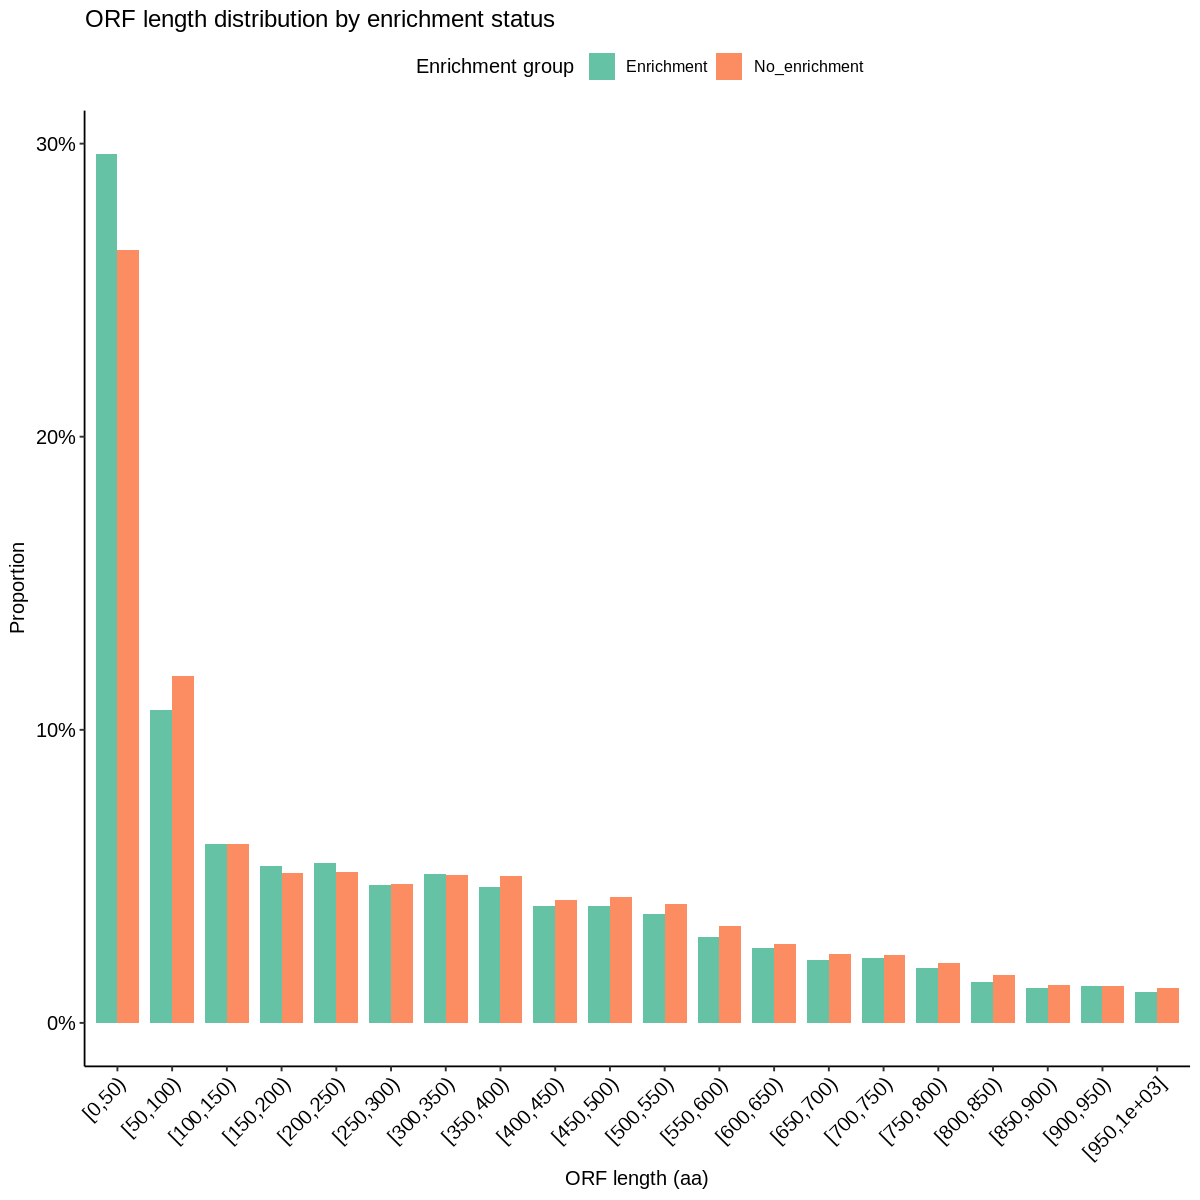

In [150]:
library(ggplot2)
library(cowplot)

# 创建 bin 分组，只保留 ORF_length < 1000 的数据
df_filtered <- df %>%
  filter(ORF_length < 1000) %>%
  mutate(length_bin = cut(ORF_length, 
                          breaks = seq(0, 1000, by = 50),
                          include.lowest = TRUE,
                          right = FALSE))

# 计算每个 bin 的相对比例
df_binned_prop <- df_filtered %>%
  group_by(Enrichment_group, length_bin) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(Enrichment_group) %>%
  mutate(proportion = count / sum(count))

# 绘制相对比例柱状图
p_length_prop <- ggplot(df_binned_prop, aes(x = length_bin, y = proportion, fill = Enrichment_group)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.8) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    x = "ORF length (aa)",
    y = "Proportion",
    title = "ORF length distribution by enrichment status",
    fill = "Enrichment group"
  ) +
  theme_3() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  scale_y_continuous(labels = scales::percent_format())

p_length_prop

ggsave(o("orf_length_distribution_proportion_0_1000.pdf"), p_length_prop, width = 10, height = 6)

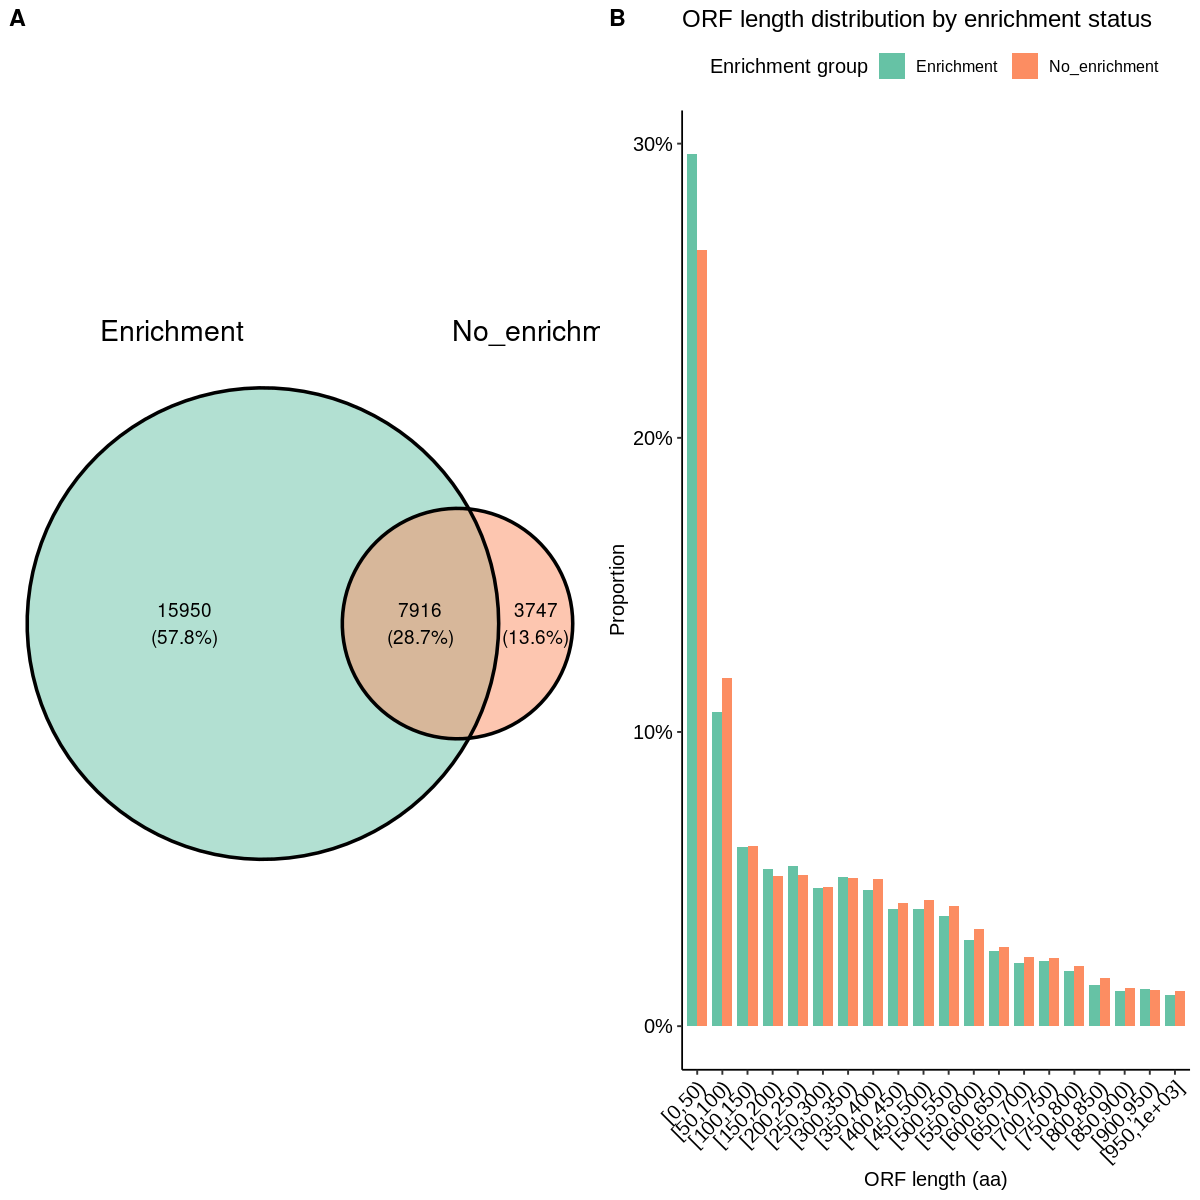

In [151]:
output_path <- "../../figures/public_in_house_compare"
combined_plot <- plot_grid( p_venn, p_length_prop, 
                            ncol = 2, nrow = 1, labels = "AUTO")
combined_plot
ggsave(filename = o("combined_plot.pdf"), plot = combined_plot, height = 5, width = 12)

# 热图

In [152]:
# 函数：将重复后缀去除，且选择指定的列进入下游分析
merge_replicate <- function(df){
    # 合并重复
    df$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", df$Sample)
    distinct(df,Protein,Sample_merge_replicate,Enzyme,Enrichment) -> df_1
    df_1 %>% rename(Sample=Sample_merge_replicate) -> df_2
    return(df_2)
}
define_type <- function(x){
    return(if_else(grepl("^sp",x) |grepl("canonical",x),"Cano","Uncano"))
}

In [153]:
# 折叠in house数据同一个富集方法以及酶切方法的样本，展示为一列
mutate(all_sample_sep_m_meta,Sample=case_when(
    grepl("21pcw",Sample) ~ Sample,
    TRUE ~ "In_house_brain"
)) -> all_sample_sep_m_meta_1
df_1 <- merge_replicate(all_sample_sep_m_meta_1)
protein_stats <- df_1 %>%
  group_by(Protein) %>%
  summarise(
    Unique_Methods = n_distinct(Enrichment),  # 被多少种不同富集方法鉴定到
    Total_Observations = n(),                 # 被鉴定到的总次数
    Supported_Enrichments = paste(sort(unique(Enrichment)), collapse = ", ")  # 支持的富集方法（去重后逗号分隔）
  )
protein_stats$Unique_Methods <- as.character(protein_stats$Unique_Methods)
protein_stats$Unique_Methods <- factor(protein_stats$Unique_Methods,levels=c('5','4','3','2','1'))
protein_stats$Type <- factor(define_type(protein_stats$Protein),levels = c("Cano","Uncano"))
protein_stats %>% arrange(Type,Unique_Methods, Supported_Enrichments,desc(Total_Observations)) -> protein_stats

In [154]:
n_distinct(df_1$Sample)
head(df_1)
head(sample_annot)

[1] 25

,Protein,Sample,Enzyme,Enrichment
,<chr>,<chr>,<chr>,<chr>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,21pcw_C8_T_T,Trypsin,C8
2,PB.1003.3:chr1:+|10|581:117:393|canonical|ATG,21pcw_C8_T_T,Trypsin,C8
3,PB.1004.25:chr1:+|3|2053:52:1792|canonical|ATG,21pcw_C8_T_T,Trypsin,C8
4,PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG,21pcw_C8_T_T,Trypsin,C8
5,PB.10048.74:chr12:+|12|1594:186:780|noncoding|ATG,21pcw_C8_T_T,Trypsin,C8
6,PB.10135.101:chr12:-|1|3224:69:2733|noncoding|ATG,21pcw_C8_T_T,Trypsin,C8


,Enrichment,Enzyme
,<chr>,<chr>
In_house_brain,No_enrichment,Trypsin
21pcw_C8_T_T,C8,Trypsin
21pcw_C8_T_AC,C8,Trypsin_ArgC
21pcw_C8_T_AN,C8,Trypsin_AspN
21pcw_C8_T_C,C8,Trypsin_Chymotrypsin
21pcw_C8_T_GC,C8,Trypsin_GluC


Warning message in brewer.pal(length(unique(protein_stats$Type)), "Set2"):
“minimal value for n is 3, returning requested palette with 3 different levels
”
'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



png 
  2

[1] "2x2列联表:"
                  
                    Cano Uncano
  Unique_Methods=1  2569  14134
  Unique_Methods>1  5601   3486
[1] "\n卡方检验结果:"

	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 5816.1, df = 1, p-value < 2.2e-16

[1] "\n期望频数:"
                  
                       Cano    Uncano
  Unique_Methods=1 5291.334 11411.666
  Unique_Methods>1 2878.666  6208.334


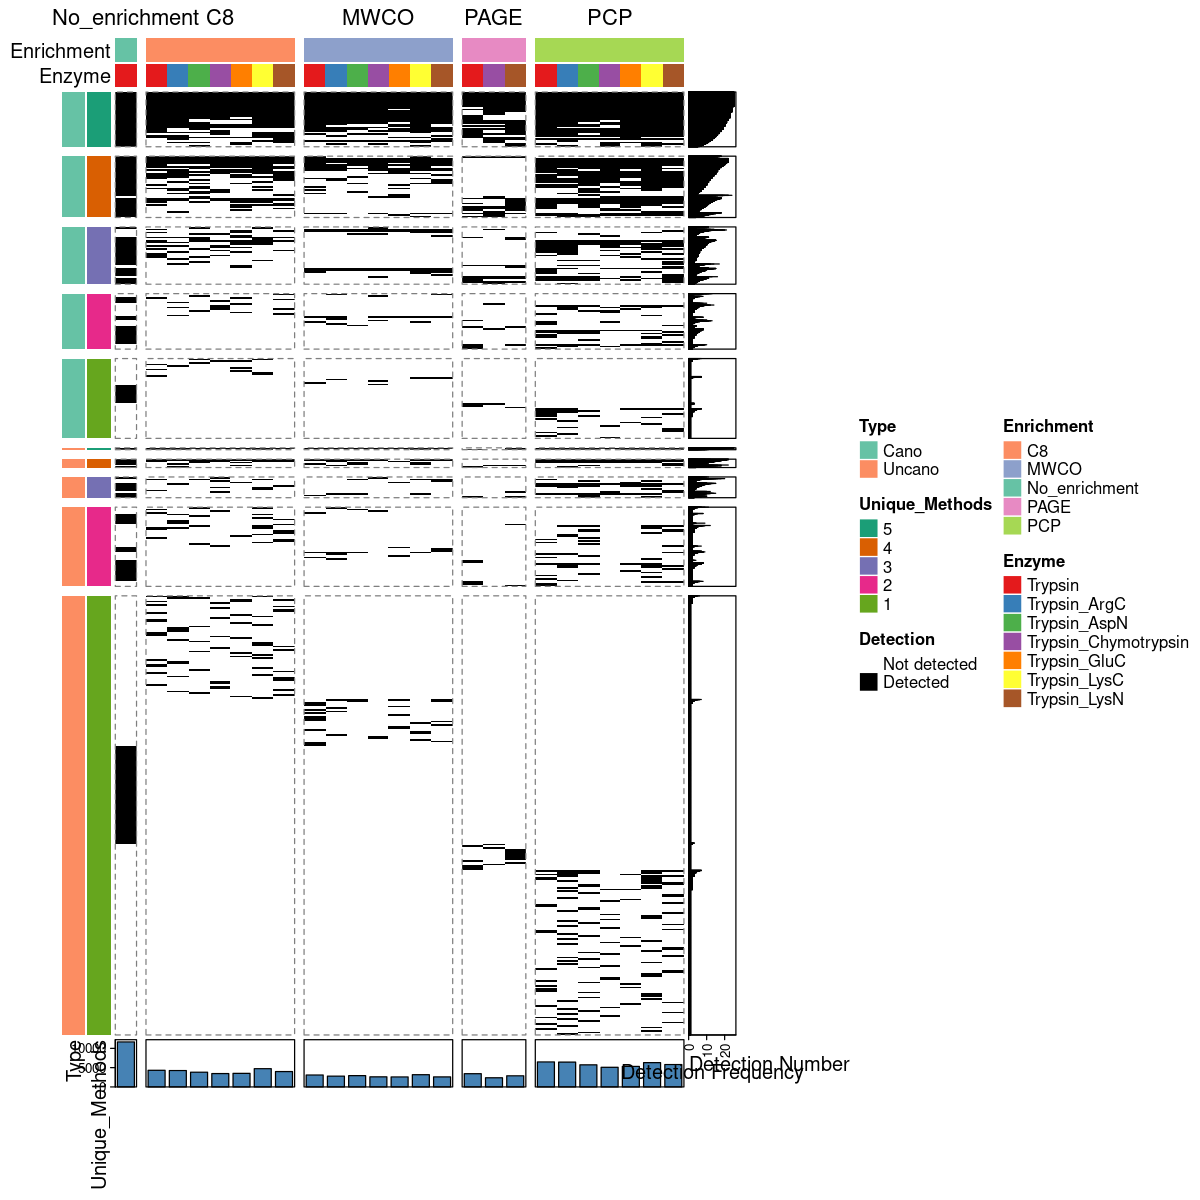

In [155]:
output_path <- "../../figures/cumu_heatmap"
library(ComplexHeatmap)
library(circlize)
# Create a binary detection matrix
binary_matrix_tmp <- df_1 %>%
  mutate(present = 1) %>%
  select(Sample, Protein, present) %>%
  pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
  column_to_rownames("Protein") %>%
  as.matrix()
# 热图的列按照特定顺序排序
c('In_house_brain',setdiff(colnames(binary_matrix_tmp),'In_house_brain')) -> new_order
binary_matrix_tmp[protein_stats$Protein,new_order] -> binary_matrix
# Calculate detection frequency for each protein
detection_freq <- rowSums(binary_matrix)
detection_number <- colSums(binary_matrix)

# Get unique sample annotations
sample_annot <- df_1 %>%
  select(Sample,Enrichment,Enzyme) %>%
  distinct() %>%
  column_to_rownames("Sample") %>% 
  .[new_order, ] 

# Define colors for annotations
enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Enzyme)), "Set1"), 
                          unique(sample_annot$Enzyme))
enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                              unique(sample_annot$Enrichment))
# Create column annotations
col_ha <- HeatmapAnnotation(
  df = sample_annot,
  col = list(
    Enzyme = enzyme_colors,
    Enrichment = enrichment_colors
  ),
  annotation_name_side = "left"
)

# Create row annotation for detection frequency
row_ha <- rowAnnotation(
  "Detection Frequency" = anno_barplot(detection_freq, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)
col_ha_1 <- columnAnnotation(
  "Detection Number" = anno_barplot(detection_number, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)

# Define colors for annotations
type_colors <- setNames(brewer.pal(length(unique(protein_stats$Type)), "Set2"), 
                          unique(protein_stats$Type))
method_colors <- setNames(brewer.pal(length(unique(protein_stats$Unique_Methods)), "Dark2"), 
                              unique(protein_stats$Unique_Methods))
protein_stats[,c("Type","Unique_Methods")]  %>% as.data.frame() -> row_anno
rownames(row_anno) <- protein_stats$Protein
# Create column annotations
row_ha_1 <- rowAnnotation(
  df = row_anno,
  col = list(
    Type = type_colors[1:2],
    Unique_Methods = method_colors
  ),
  annotation_name_side = "bottom"
)

column_split <- factor(
  sample_annot$Enrichment, 
  levels = unique(sample_annot$Enrichment) 
)
groups <- paste0(protein_stats$Type,"-",protein_stats$Unique_Methods)
row_split <- factor(
    groups, 
    levels = unique(groups)
)

options(repr.plot.width = 10, repr.plot.height = 10)

ht <- Heatmap(
    binary_matrix,
    name = "Detection",
    col = c("white", "black"),
    cluster_columns = FALSE,
    clustering_distance_columns="binary",
    cluster_rows = FALSE,
    row_title=NULL,
    show_row_names = FALSE,
    show_column_names = FALSE,
    top_annotation = col_ha,
    right_annotation = row_ha,
    left_annotation = row_ha_1,
    bottom_annotation = col_ha_1,
    column_split = column_split,
    row_split = row_split,
    heatmap_legend_param = list(
        at = c(0, 1),
        labels = c("Not detected", "Detected")
    ),
    # 使用raster后续在AI里面不会那么卡
    use_raster = TRUE,
     raster_quality = 0.01,
    # 添加虚线分隔
    row_gap = unit(2, "mm"),
    column_gap = unit(2, "mm"),
    border_gp = gpar(lty = "dashed", col = "grey50")  # 替代方法
)
ht

# Draw the heatmap
# 1. 打开 PDF 设备，设置文件名和尺寸（单位：英寸）
pdf(o("protein_detection_heatmap.pdf"), width = 12, height = 12)
# 2. 绘制热图（假设 `ht` 是你的 Heatmap 对象）
draw(ht)
# 3. 关闭设备，保存文件
dev.off()

# 自动生成2x2列联表
library(dplyr)

# 创建分组变量
protein_stats_grouped <- protein_stats %>%
  mutate(
    Group = case_when(
      Unique_Methods == "1" ~ "Unique_Methods=1",
      Unique_Methods %in% c("2", "3", "4") ~ "Unique_Methods>1"
    )
  )

# 生成列联表
contingency_table <- table(protein_stats_grouped$Group, protein_stats_grouped$Type)
print("2x2列联表:")
print(contingency_table)

# 进行卡方检验
chi_test <- chisq.test(contingency_table)
print("\n卡方检验结果:")
print(chi_test)

# 检查期望频数
print("\n期望频数:")
print(chi_test$expected)

# 如果期望频数<5，使用Fisher精确检验
if(any(chi_test$expected < 5)) {
  print("\n期望频数<5，使用Fisher精确检验:")
  fisher_test <- fisher.test(contingency_table)
  print(fisher_test)
}

In [23]:
colnames(protein_stats_grouped)
protein_stats_grouped %>% group_by(Type,Unique_Methods) %>% summarise(n=n())

[1] "Protein"               "Unique_Methods"        "Total_Observations"   
[4] "Supported_Enrichments" "Type"                  "Group"

`summarise()` has grouped output by 'Type'. You can override using the
`.groups` argument.


Type,Unique_Methods,n
<fct>,<fct>,<int>
Cano,5,1762
Cano,4,1973
Cano,3,1843
Cano,2,1785
Cano,1,2569
Uncano,5,61
Uncano,4,269
Uncano,3,667
Uncano,2,2550


# 经典和非经典的比较

In [157]:
orfs_path <- "../../results/orfs_merged_final.tsv"
fread_c(orfs_path)  %>% filter(!grepl("Cont",ORF_id)) -> df
df %>% mutate(Unique_peptide_n_1=
                case_when(Unique_peptide_n > 2 ~ ">2",
                          TRUE ~ as.character(Unique_peptide_n))) -> df
df$Unique_peptide_n_1 <- factor(df$Unique_peptide_n_1,levels = c("1","2",">2"))
df %>% mutate(Cano_type=
                case_when(ORF_type == "canonical" ~ "Canonical",
                          TRUE ~ "Non-canonical")) -> df
count(df,Cano_type,Unique_peptide_n_1) -> df_1
df_1$Cano_type <- factor(df_1$Cano_type,levels = c("Non-canonical","Canonical"))
df_1$Unique_peptide_n <- factor(df_1$Unique_peptide_n,levels = c(">2","2","1"))

# 图片输出路径
output_path <- "../../figures/cano_noncano_compare"

## 肽段支持比较

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


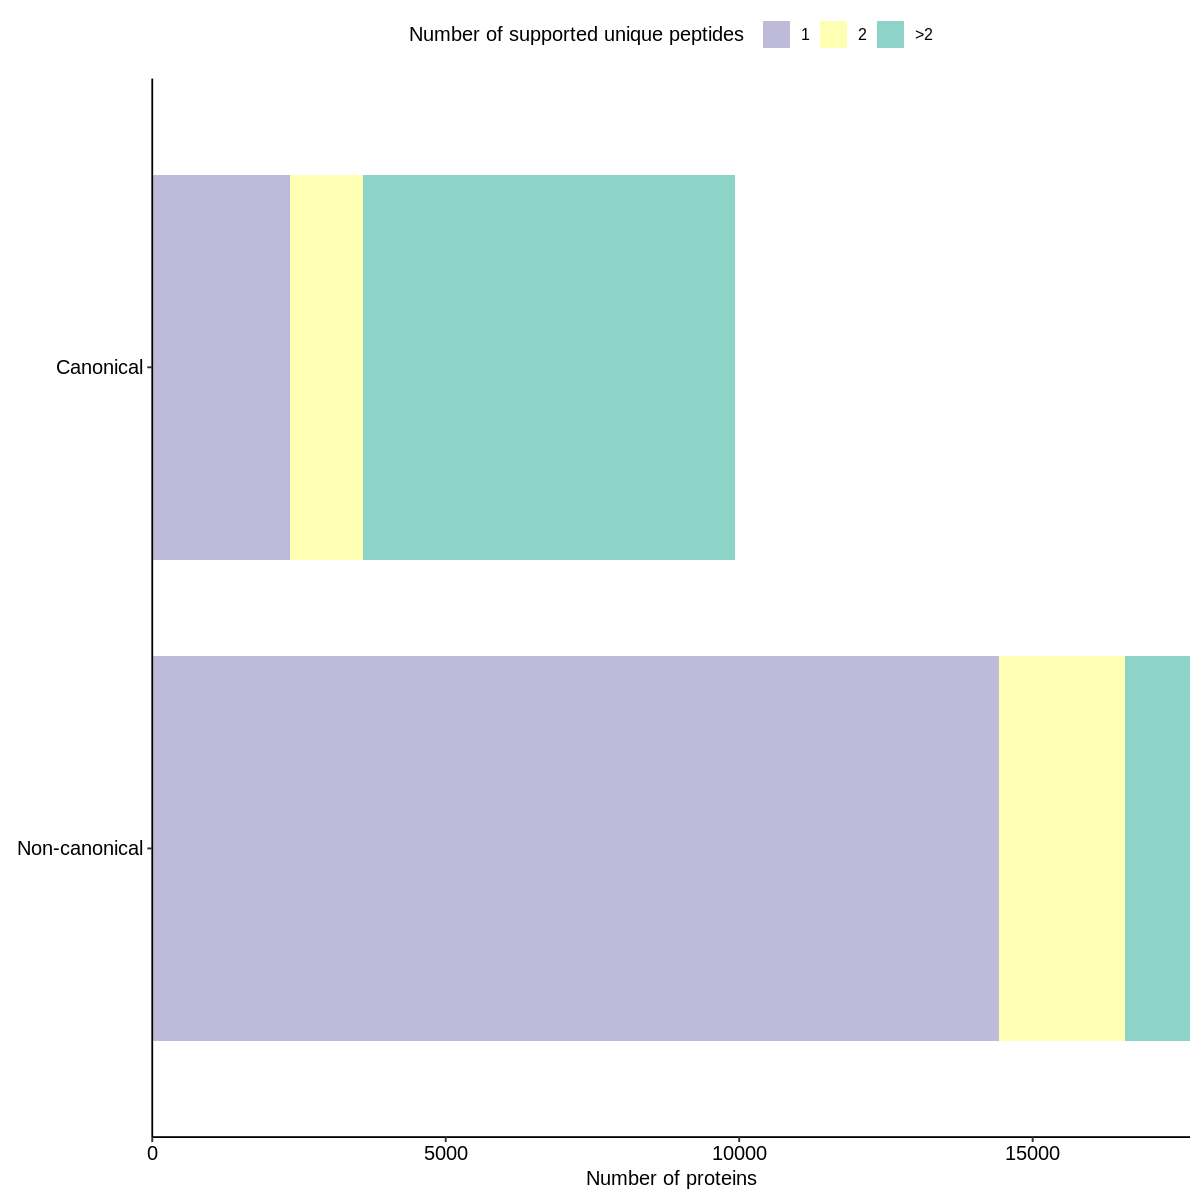

In [158]:
bar_plot_basic_stack(df = df_1,x = "Cano_type",y ="n" ,fil_col = "Unique_peptide_n")+
scale_fill_manual(values = brewer.pal(n=3,name="Set3"))+
coord_flip()+
guides(fill = guide_legend(reverse = TRUE))+
labs(x=NULL,y="Number of proteins",fill="Number of supported unique peptides")-> p_unique_peptide
p_unique_peptide
ggsave(p_unique_peptide,filename = o("unique_peptide_n_compare.pdf"),height = 5,width = 5)

In [159]:
# head(df_1)
df_1 %>% filter(Cano_type=="Canonical") %>% mutate(Pro=n/sum(n))
df_1 %>% filter(Cano_type=="Non-canonical") %>% mutate(Pro=n/sum(n))

Cano_type,Unique_peptide_n_1,n,Unique_peptide_n,Pro
<fct>,<fct>,<int>,<fct>,<dbl>
Canonical,1,2353,1,0.2369110
Canonical,2,1244,2,0.1252517
Canonical,>2,6335,>2,0.6378373


Cano_type,Unique_peptide_n_1,n,Unique_peptide_n,Pro
<fct>,<fct>,<int>,<fct>,<dbl>
Non-canonical,1,14430,1,0.81613031
Non-canonical,2,2136,2,0.12080765
Non-canonical,>2,1115,>2,0.06306204


## 长度比较

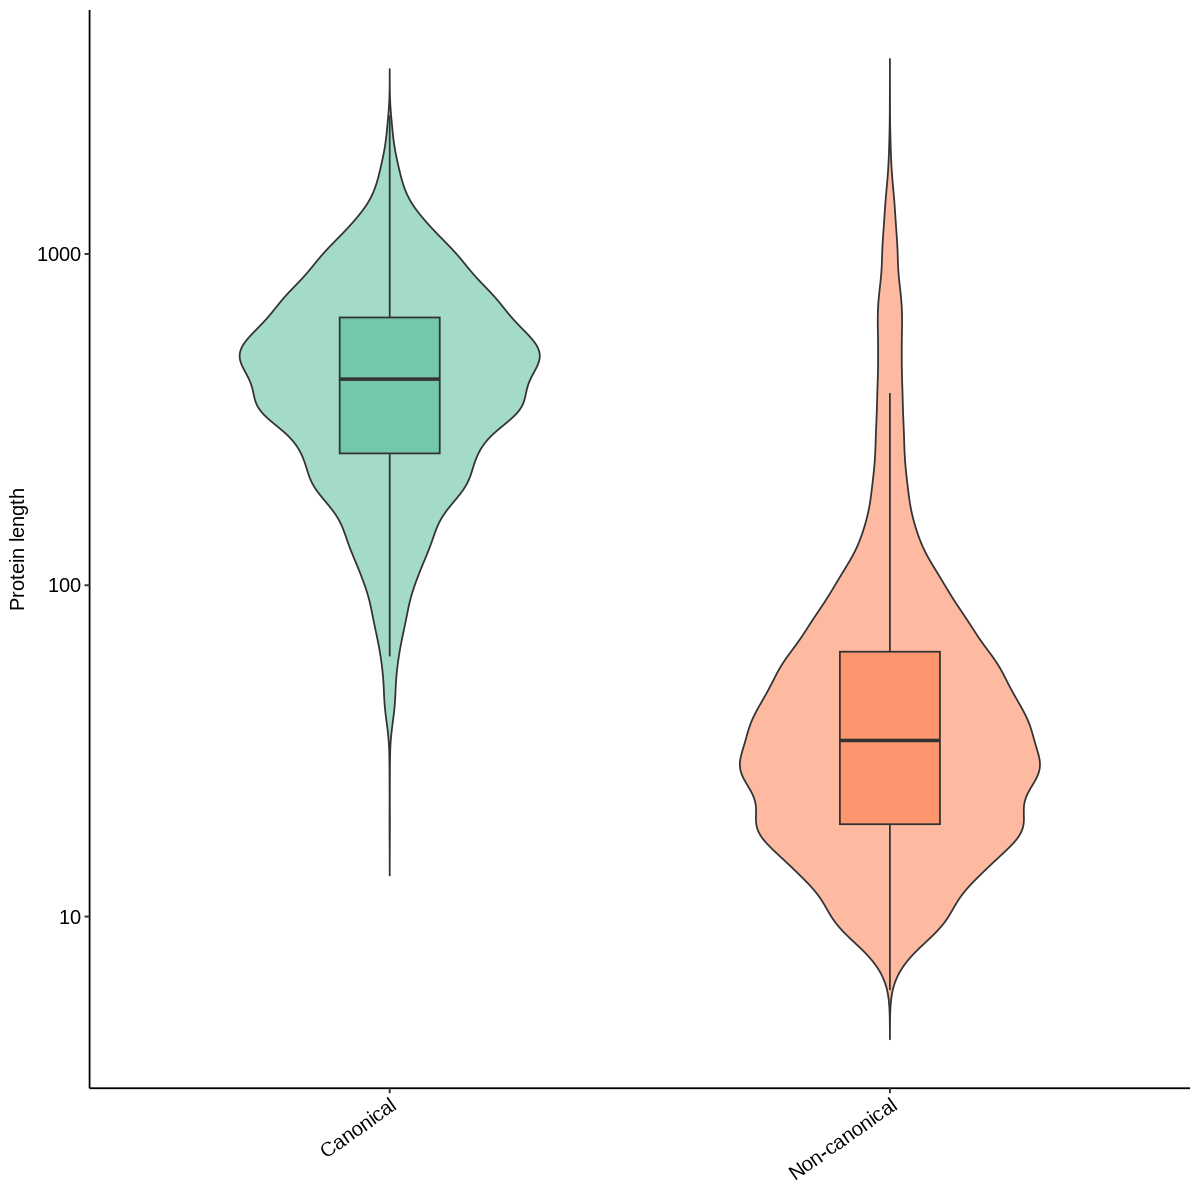

In [160]:
# violin_plot(df,x = "Cano_type",y = "ORF_length",fill_col = "Cano_type")
violin_plot_1(df,x = Cano_type,y = ORF_length,fill = Cano_type,y_label = "Protein length")+scale_y_log10()-> p_length_violin
p_length_violin
ggsave(p_length_violin,filename = o("orf_length_compare.pdf"),height = 5,width = 5)

In [161]:
df %>% filter(Cano_type=="Canonical") %>% .$ORF_length %>% summary()
df %>% filter(Cano_type=="Non-canonical") %>% .$ORF_length %>% summary()

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   18.0   250.0   419.0   492.8   643.0  2671.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   6.00   19.00   34.00   81.74   63.00 2755.00 

## 检测可重复性

,Run_occurrence,n,Type
,<int>,<int>,<chr>
1,1,1803,Canonical
2,2,941,Canonical
3,3,693,Canonical
4,4,525,Canonical
5,5,372,Canonical
6,6,311,Canonical


,Run_occurrence,n,Type,Group
,<int>,<int>,<chr>,<chr>
1,1,1803,Canonical,Detection=1
2,2,941,Canonical,Detection>1
3,3,693,Canonical,Detection>1
4,4,525,Canonical,Detection>1
5,5,372,Canonical,Detection>1
6,6,311,Canonical,Detection>1


`summarise()` has grouped output by 'Group'. You can override using the
`.groups` argument.


[1] "2x2列联表:"
              Detection=1 Detection>1
Canonical            1803        8129
Non-canonical       12029        5652
[1] "\n卡方检验结果:"

	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 6327.1, df = 1, p-value < 2.2e-16



[1] 0.8184656

[1] 0.3196652

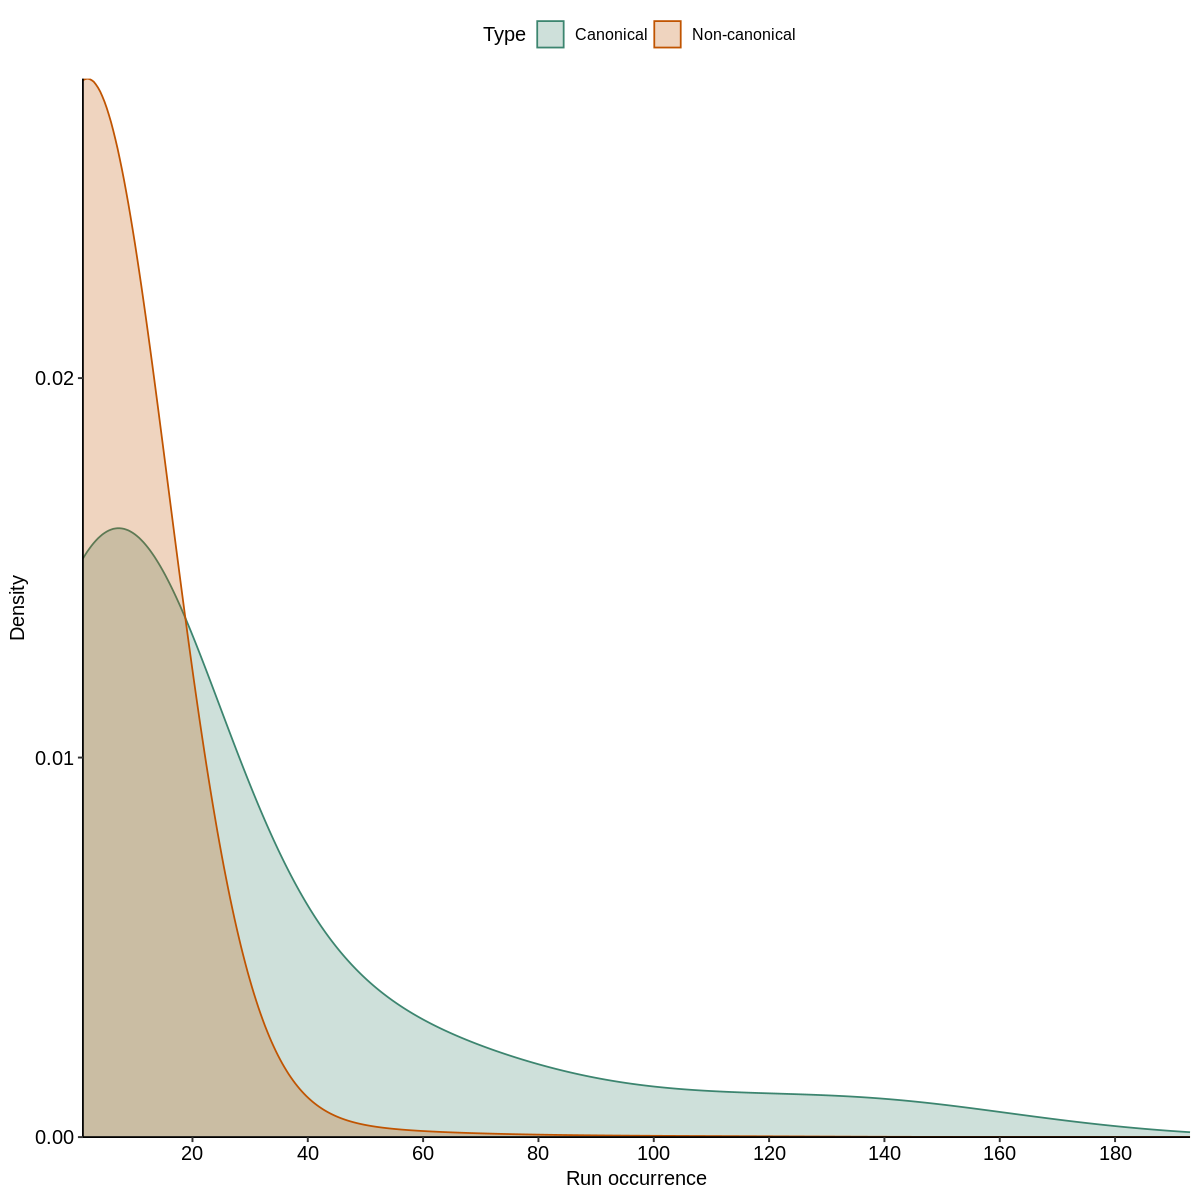

In [162]:
# orfs -> df
df %>% filter(ORF_type=="canonical") %>% count(Run_occurrence)-> protein_detection_n_cano
protein_detection_n_cano$Type <- "Canonical"
df %>% filter(ORF_type!="canonical") %>% count(Run_occurrence) -> protein_detection_n_uncano
protein_detection_n_uncano$Type <- "Non-canonical"
rbind(protein_detection_n_cano,protein_detection_n_uncano) -> protein_detection_n
head(protein_detection_n)
protein_detection_n %>%
  mutate(
    Group = case_when(
      Run_occurrence == 1 ~ "Detection=1",
      Run_occurrence > 1  ~ "Detection>1"
    )
  )->tmp
head(tmp)
# 生成列联表
contingency_table <- tmp %>% group_by(Group,Type) %>% summarise(sum_n=sum(n)) %>% 
pivot_wider(values_from = sum_n,names_from =Group ) %>% column_to_rownames("Type")
print("2x2列联表:")
print(contingency_table)

# 进行卡方检验
chi_test <- chisq.test(contingency_table)
print("\n卡方检验结果:")
print(chi_test)

# 被两次及以上的MS run支持的比例
calcu_pro <- function(df){
    1-df$n[1]/sum(df$n)
}
calcu_pro(protein_detection_n_cano)
calcu_pro(protein_detection_n_uncano)
library(RColorBrewer)
library(scales)

cols <- darken(brewer.pal(3, "Set2")[1:2], 0.3)
# cols <- desaturate(brewer.pal(3, "Set3")[1:2],-0.5)

p_dens <- ggplot(protein_detection_n,
                 aes(x = Run_occurrence, weight = n, colour = Type, fill = Type)) +
  geom_density(alpha = 0.25, adjust = 1) +
  scale_y_continuous(expand = c(0, 0)) +
scale_x_continuous(expand = c(0, 0),breaks = seq(0,200,20)) +
  theme_3(rotate = FALSE) +
  scale_fill_manual(values = cols) +
  scale_colour_manual(values = cols) +
  labs(x = "Run occurrence",
       y = "Density", colour = "Type", fill = "Type")

p_dens
ggsave(filename = o("run_occurrence_compare.pdf"), plot = p_dens, height = 5, width = 8)

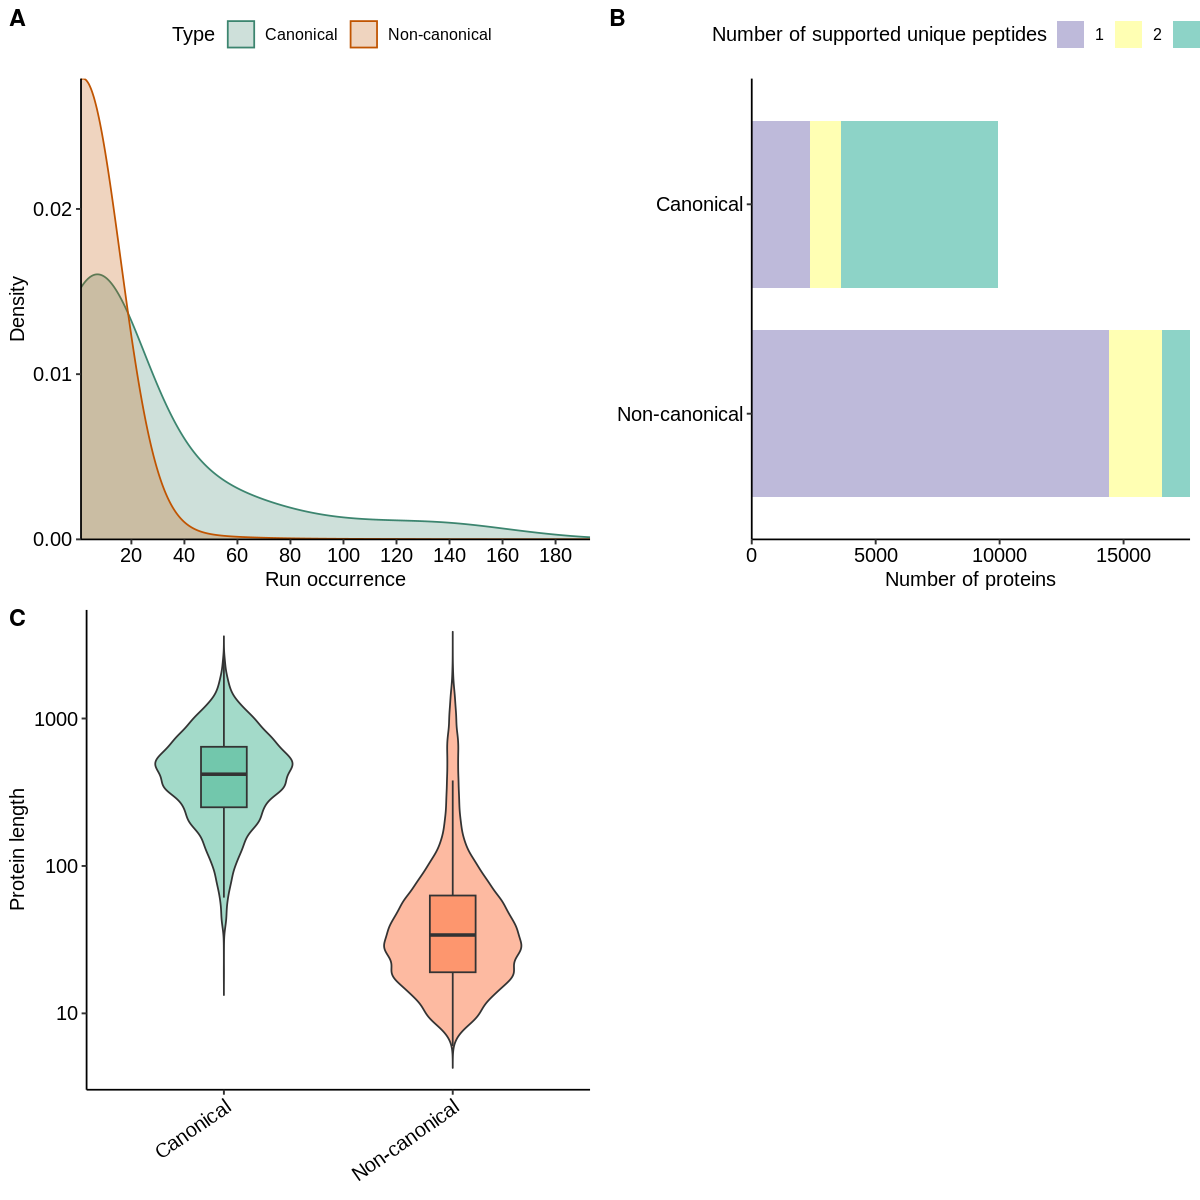

In [106]:
combined_plot1 <- plot_grid(p_dens, p_unique_peptide, p_length_violin, 
                            ncol = 2, nrow = 2, labels = "AUTO")
combined_plot1
ggsave(filename = o("combined_plot1.pdf"), plot = combined_plot1, height = 10, width = 8)